In [2]:
import matplotlib.pyplot as plt
import numpy as np
import sys
import os
import h5py
import matplotlib.colors as colors
import matplotlib.cm
from scipy.ndimage import gaussian_filter

#####Import Ollie Tools
dirPath = "C:/Coding"
sys.path.insert(0, dirPath)
import OllieTools as oj
print(dirPath)


####Import Ollie Tools MAC
# dirPath = "/Users/olliejackson/Coding"
# sys.path.insert(0, dirPath)
# import OllieTools as oj
# print(dirPath)

oj.thesis_plot_settings()

C:/Coding/Code
C:/Coding
Thesis plot settings applied


C:\Users\u2088308\AppData\Local\Temp\ipykernel_26700\1752709716.py:38: RankWarning: Polyfit may be poorly conditioned
  pr = np.poly1d(np.polyfit(r2, U_r2, 21))(r2) #This turns the graph into a polynomial line
C:\Users\u2088308\AppData\Local\Temp\ipykernel_26700\1752709716.py:43: RankWarning: Polyfit may be poorly conditioned
  paz = np.poly1d(np.polyfit(r2, U_az2, 21))(r2)
C:\Users\u2088308\AppData\Local\Temp\ipykernel_26700\1752709716.py:38: RankWarning: Polyfit may be poorly conditioned
  pr = np.poly1d(np.polyfit(r2, U_r2, 21))(r2) #This turns the graph into a polynomial line
C:\Users\u2088308\AppData\Local\Temp\ipykernel_26700\1752709716.py:43: RankWarning: Polyfit may be poorly conditioned
  paz = np.poly1d(np.polyfit(r2, U_az2, 21))(r2)
C:\Users\u2088308\AppData\Local\Temp\ipykernel_26700\1752709716.py:38: RankWarning: Polyfit may be poorly conditioned
  pr = np.poly1d(np.polyfit(r2, U_r2, 21))(r2) #This turns the graph into a polynomial line
C:\Users\u2088308\AppData\Local\Temp

(7659,)


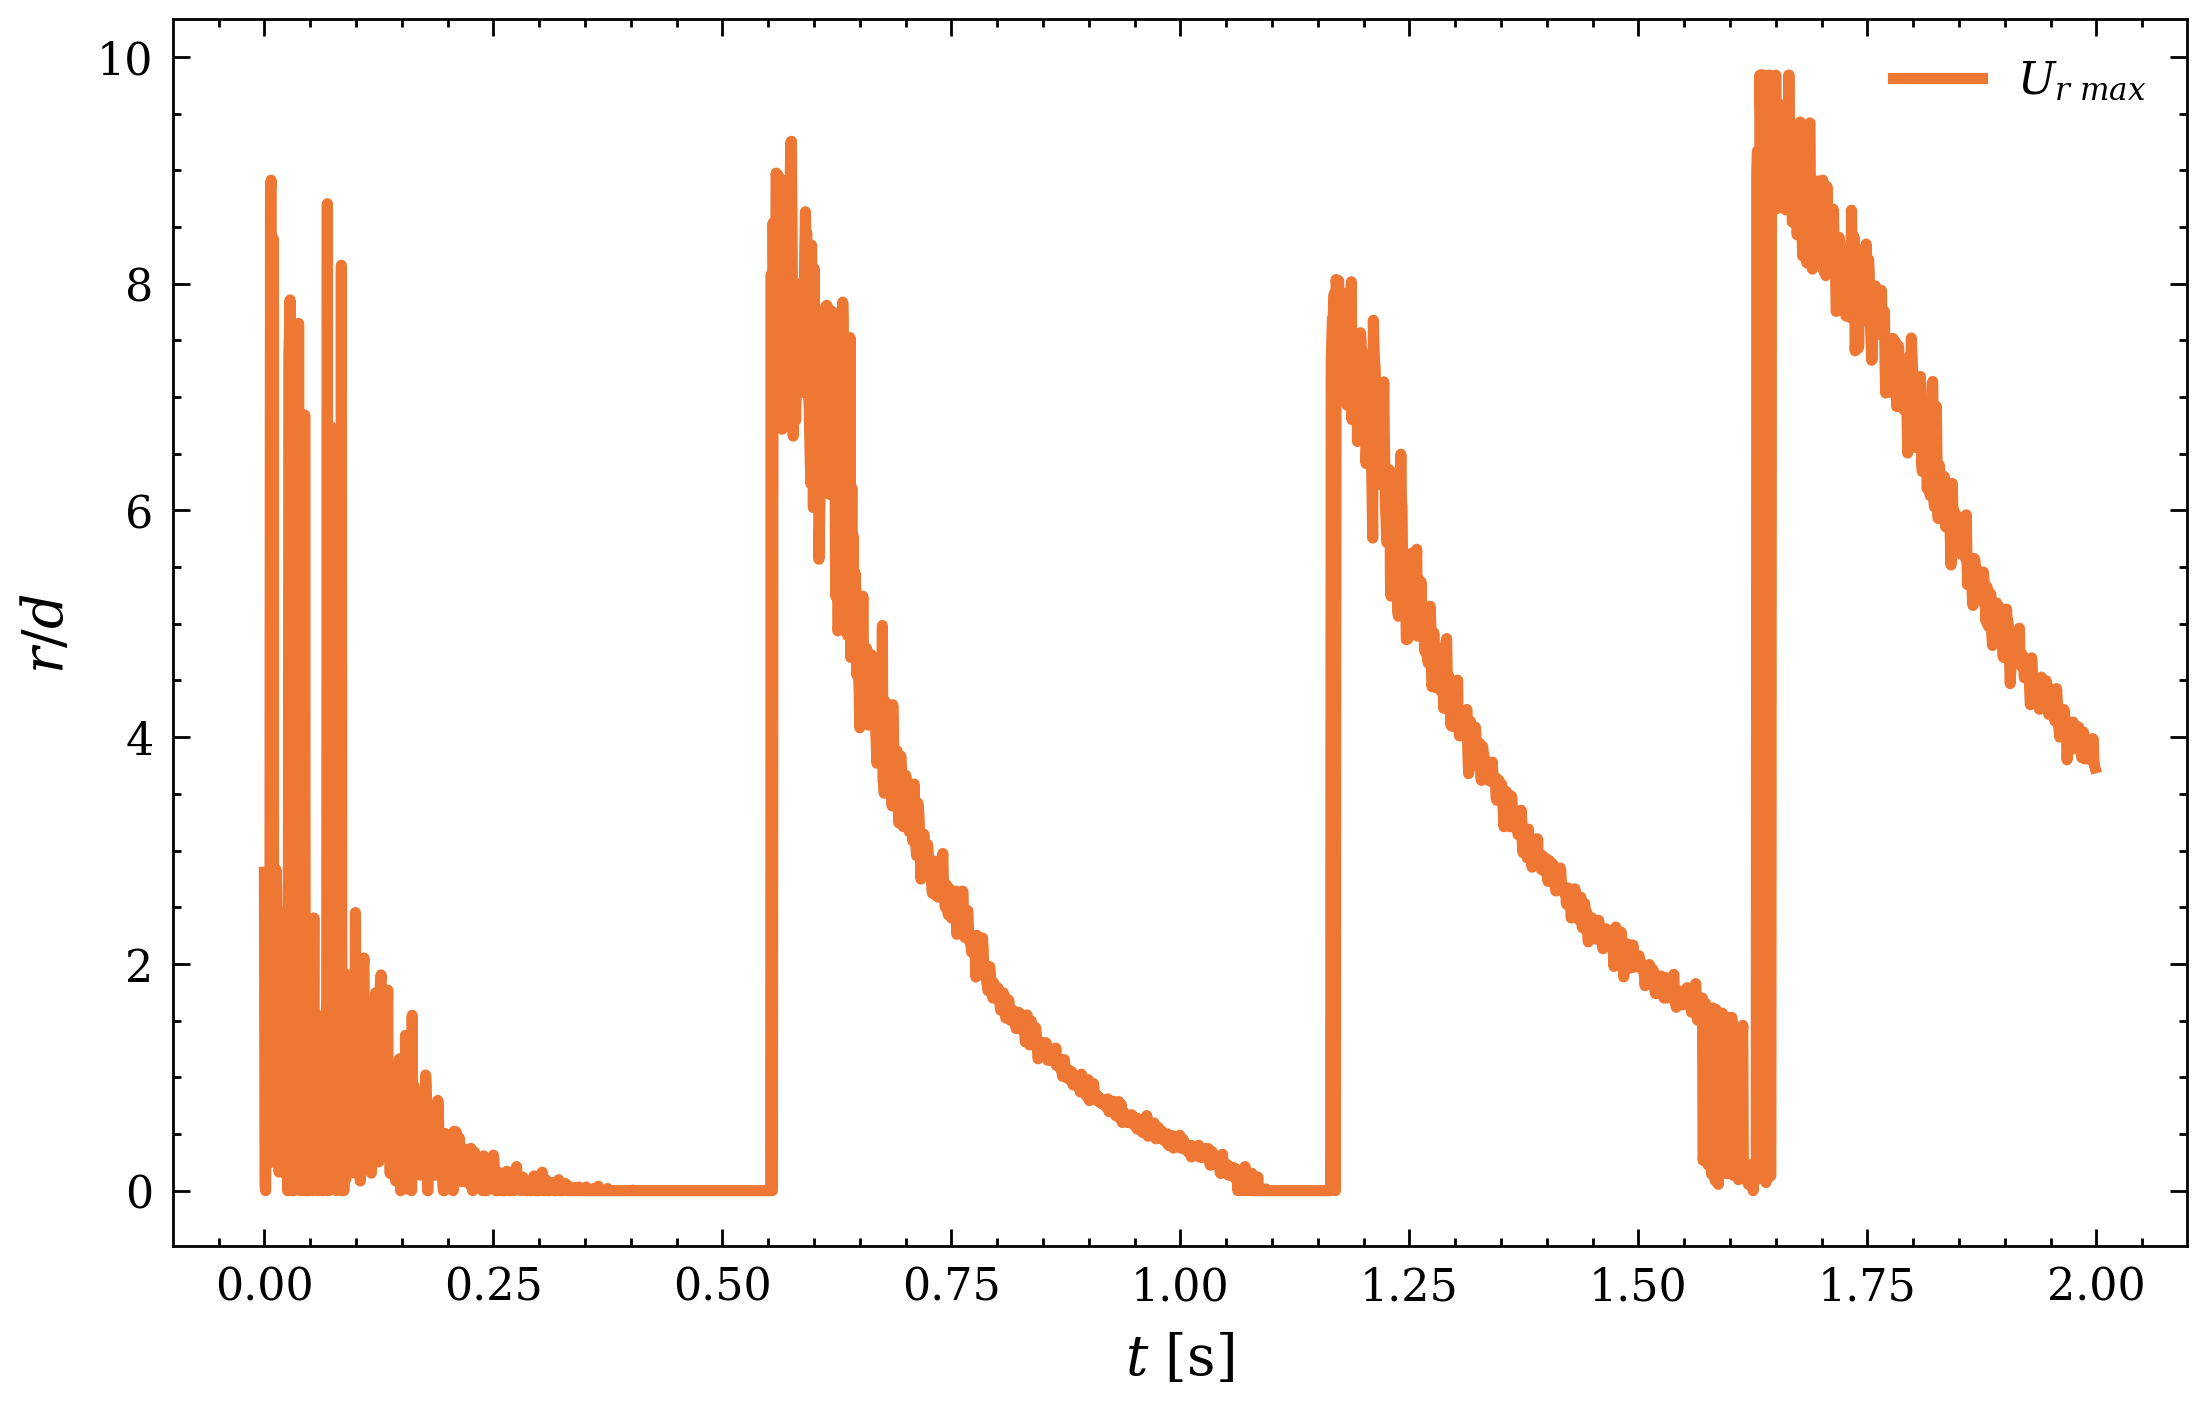

In [61]:
# h5file = h5py.File('E:/H5/3D0HLSFine.h5', 'r')
h5file = h5py.File('E:/H5/3D0meandataHLS.h5', 'r')


vels = h5file['3D0']['U100']['L100']['RPM6']
u = vels[:,:,:,0]
v = vels[:,:,:,1]
r_nd, z_nd = oj.NDUnitsForPlotsHoriz(u.shape[1], u.shape[2])
time = oj.frames_to_seconds(u, v, 150)
frames0 = [750, 1020, 1470]

# u, v = gaussian_filter(u, 1), gaussian_filter(v, 1)

x = np.linspace(0 , u.shape[2], u.shape[2])
y = np.linspace(0 , u.shape[1], u.shape[1])
xc = u.shape[2]/2
yc = u.shape[1]/2


d=0.05
fig, ax = plt.subplots(1, figsize=(5.5, 3.5), dpi = 400)

radial_Positionr = np.zeros([u.shape[0]])
U_r_Mean =         np.zeros([u.shape[0]])
U_r_Peak =         np.zeros([u.shape[0]])

radial_Positionaz = np.zeros([u.shape[0]])
U_az_Mean =         np.zeros([u.shape[0]])
U_az_Peak =         np.zeros([u.shape[0]])


for i in range(u.shape[0]):
# for i in range(1):
    r, theta, U_r, U_az, x0, y0 = oj.ConvertCylindrical(xc, yc, x, y, u[i,:,:], v[i,:,:])
    inds = (r.flatten()).argsort()
    r2 = (r.flatten())[inds]
    U_r2 = (U_r.flatten())[inds]
    pr = np.poly1d(np.polyfit(r2, U_r2, 21))(r2) #This turns the graph into a polynomial line
    # radial_Positionr[0, i] = np.argmax(pr)
    U_r_Mean[i] = np.mean(U_r2)
    radial_Positionr[i] = np.argmax(pr[200:6000])
    U_az2 = (U_az.flatten())[inds]
    paz = np.poly1d(np.polyfit(r2, U_az2, 21))(r2)
    # radial_Positionaz[0, i] = np.argmax(paz)
    U_az_Mean[i] = np.mean(U_az2)
    radial_Positionaz[i] = np.argmax(U_az2)
print(inds.shape)

# ax.plot(time, radial_Positionr[:]/u.shape[2], label=fr'$t$')
ax.plot(time*6/60, radial_Positionr[:]/inds.shape*13, label=r'$U_{r~max}$')
ax.set_xlabel('$t$ [s]')
ax.set_ylabel(r'$r/d$')
ax.legend(fontsize=8)

radial_Position = np.zeros(u.shape[0])
U_r_Mean = np.zeros(u.shape[0])
U_r_Peak = np.zeros(u.shape[0])

